In [277]:
import numpy as np
import matplotlib.pyplot as plt

In [278]:
# Definerer klassen for spillere
class player:
    def __init__(self, power: int):
        self.elo = 1000
        self.power = power if power > 0 else 0
        self.name = f"playerWithPower {power}"
        self.numMatches = 0
        self.eloHistory = [self.elo]

    def __str__(self):
        return f"{self.name:<22} Elo: {self.elo:<8} NumMatches: {self.numMatches}"

    def completeMatch(self, newElo):
        self.numMatches += 1
        self.elo = newElo
        self.eloHistory.append(newElo)

In [279]:
# Lager en liste med spillere
# Spillerne får gradvis høyere power, men det er litt randomisert
# Bedre spillere får større mulig intervall
def generatePlayers(numPlayers: int):
    players = []
    powers = [] 
    for i in range(0, numPlayers):
        power = np.random.randint(10 * i, 10 * i + 2 * i**2 / numPlayers + 5 * numPlayers)
        players.append(player(power))
        powers.append(power)


    plt.plot(powers, marker="o", linewidth=1)
    plt.grid()
    plt.show()
    
    players.sort(key=lambda p: p.power, reverse=True)

    
    return players

In [280]:
# Funksjon for å finne to konkurrenter
def findMatch(players: list[player]) -> player:
    if players is None:
        raise ValueError("players is None")
    matchNumbers =[]
    for i in range(0, len(players)):
        matchNumbers.append(players[i].numMatches)

    # Finn den femte laveste verdien i matchNumbers
    distinct = sorted(set(matchNumbers))
    if len(distinct) < 5:
        numMatchesEligible = distinct[-1]
    else:
        numMatchesEligible = distinct[4]

    playerPool = [p for p in players if p.numMatches <= numMatchesEligible]
    p1Index = np.random.randint(0, len(playerPool))
    player1 = playerPool[p1Index]
    playerPool.remove(player1)
    player2 = playerPool[np.random.randint(0, len(playerPool))]

    return player1, player2

In [281]:
def match(player1: player, player2: player, f: int, K: int):
    R_1 = player1.elo
    R_2 = player2.elo

    E_1 = 1 / (1 + 10 ** ((R_2 - R_1) / f))
    E_2 = 1 / (1 + 10 ** ((R_1 - R_2) / f))

    # Finner ut hvem som vinner
    # Skalerer slik at spiller 1 har power1 / power_tot sjanse for å vinne

    power1 = player1.power
    power2 = player2.power

    p1wins = power1 / (power1 + power2)
    result = np.random.random()
    S_1 = int(result < p1wins)
    S_2 = int(result >= p1wins)
    
    R_1_new = R_1 + K * (S_1-E_1)
    R_2_new = R_2 + K * (S_2-E_2)
    
    player1.completeMatch(R_1_new)
    player2.completeMatch(R_2_new)

In [282]:
def simulateTournament(players, f=400, K = 32, totalNumMatches=1000):
    for i in range(totalNumMatches):
        player1, player2 = findMatch(players)
        match(player1, player2, f, K)
    
    # return players
    plt.figure(figsize=(14,8))
    for p in players:
        plt.plot(p.eloHistory, linewidth="1", label=p.name)
        
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

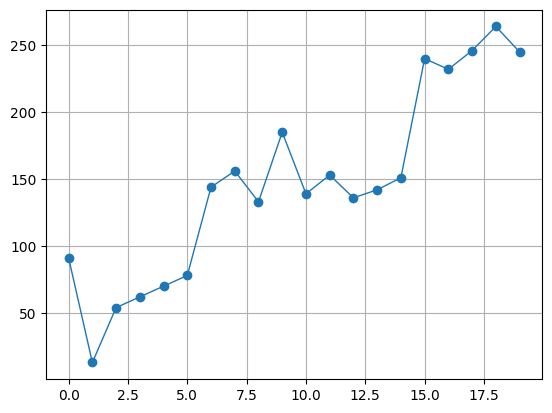

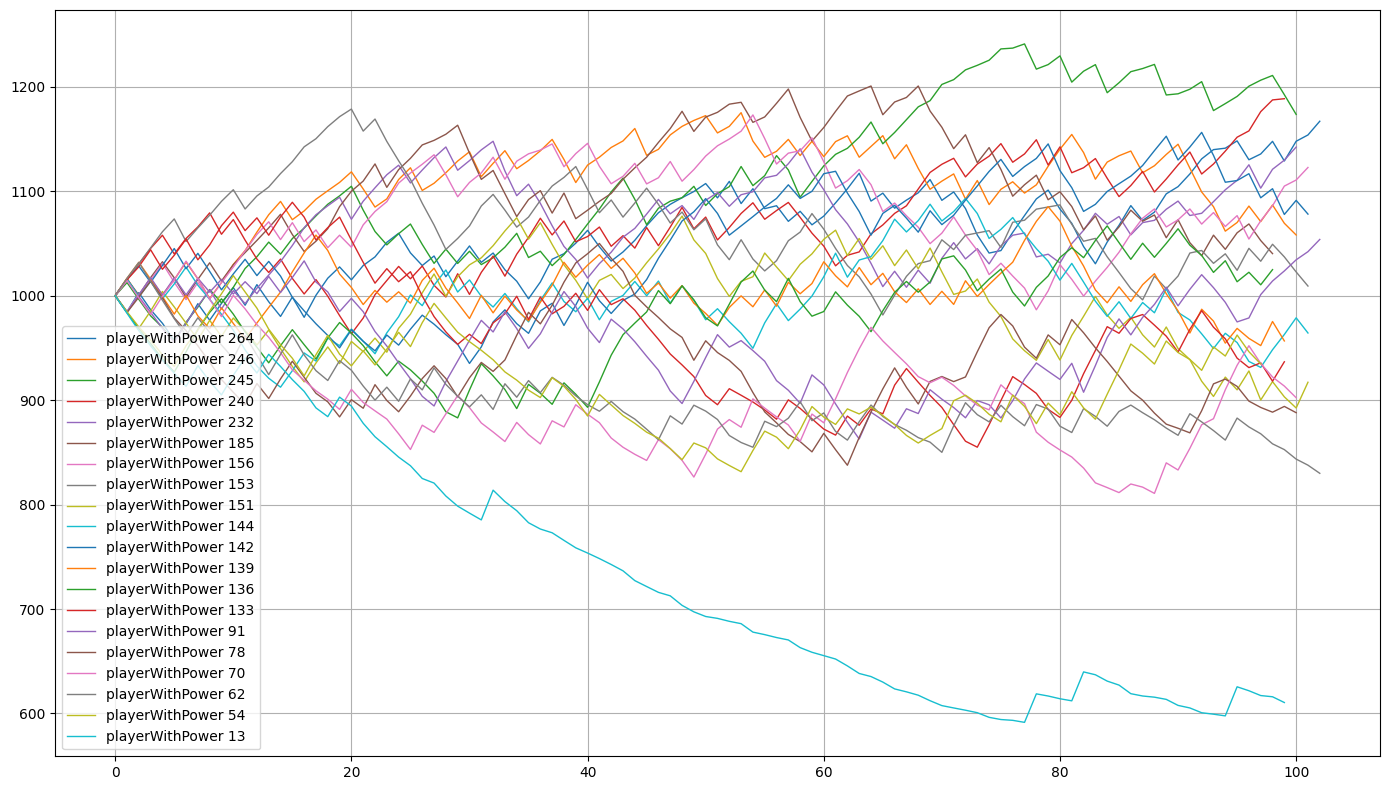

In [285]:
players = generatePlayers(20)
simulateTournament(players, totalNumMatches=1000)